The method I use：  
ka_ves0 the vescle particle bind affinity. ( ka_ves0 = pat.ka(CellType, R_ves, polymerization, ParType="Vesicle"))
The fitting differential equations:  

$$ \frac{\partial \theta_{t}}{\partial t} = {\color {red} k_{on}}(\rho_{P_{t}}-\rho_{C_{0}}\theta_{t})(1-\theta_{t})-k_{off}\theta_{t} - k_{e}\rho_{P_{t}}$$

$$ \frac{\partial \rho_{t}}{\partial t} = - {\color{red}k_{e}}\rho_{P_{t}}\rho_{C_{0}} $$


We use the <span style="color: green;"> bind_ves( ), bind_mi( ) and bind_tu()</span> to bulid the eqautions(1) and (2). ft[0] is the time dependence of surface coverage. ft[1] is the time dependence of the particle concentration.    

We use <span style="color: green;">sci.solve_ivp(func, t[t0, tx], initial_y[y1, y2])</span> to solve the differential equation and use <span style="color: green;">sci.curve_fit(func, x, y bounds=boundary_condition[x1, x2, x3])</span> to fit the data.  
Step 1:  Get the data for different particles. 
    
Step2: We build the function describe the differential equations <span style="color: green;"> bind_ves(t, ft)</span>. When $t>t_{endo}$, there is ednocytosis. The code: <span style="color: green;"> res = solve_ivp(bind_ves, (0, 6000), [0, rho_P_ves], t_eval=t_fit_ves) </span> gives the result of<span style="color: green;"> ft</span> for different $k_{on}, k_{off}, \alpha$ and $\beta$. Code: <span style="color: green;">res.y[0, :]</span> to get the fitting result.

Step3: Define the fitting function.  Function:<span style="color: green;"> fit_fun_ves(t, kon0,b0, ki)</span> have different result with different parameters.     
    Then we can fit the fucntion use the function for scipy: <span style="color: green;"> popt, *pcov = sci.curve_fit(fit_fun, t_fit, data_fit, bounds=bound)</span>. <span style="color: green;"> bound </span>is the boundary condition; <span style="color: green;"> popt </span> is parameter value of the fitting result; <span style="color: green;"> *pcov </span> should be the least square between the data and fitting result; 

We get the fitting results and plot the figures.


Density of vesicle, 1.0058119070821789e-12 
 Density of micelle 5.344862843871105e-11 
 Density of tube: 2.2176864659588327e-13
Vesicle [9.05392145e+09 1.25107546e-06 5.75236008e-02 7.35131594e-01
 9.69624436e-03] Micelle [1.69397147e+08 1.00000000e-04 4.61519564e-03 4.42581655e-15
 1.90673766e-03] Tube [5.49247405e+09 1.00000008e-06 4.44338470e-01 8.37554571e-10]
Avidity vesicle: 7.24e+15 micelle: 1.69e+12 tube: 5.49e+15


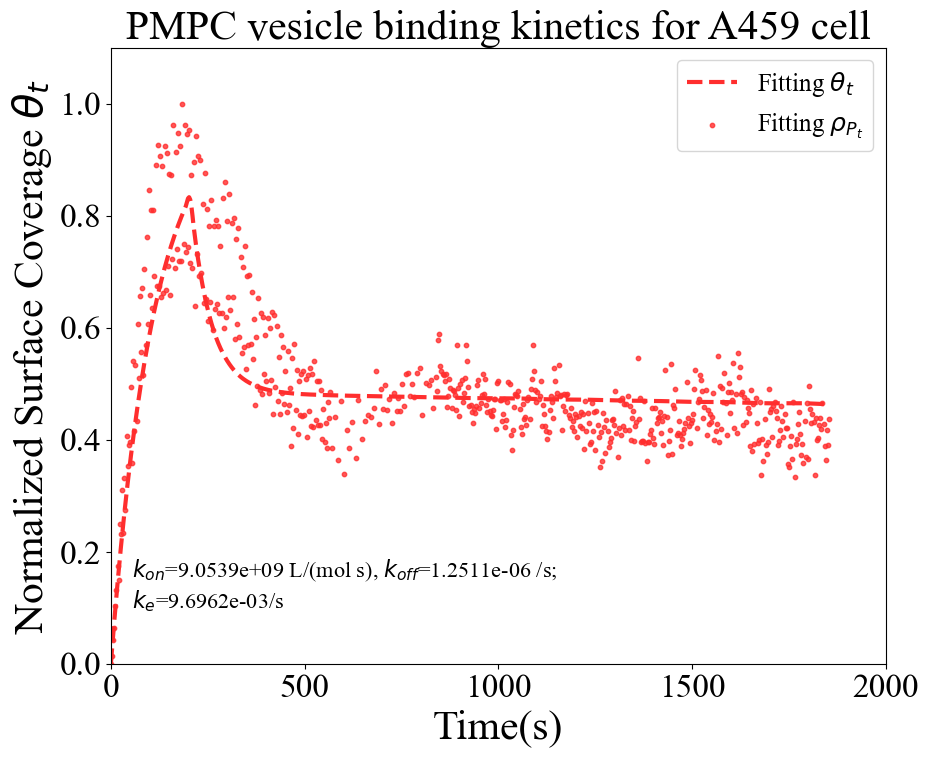

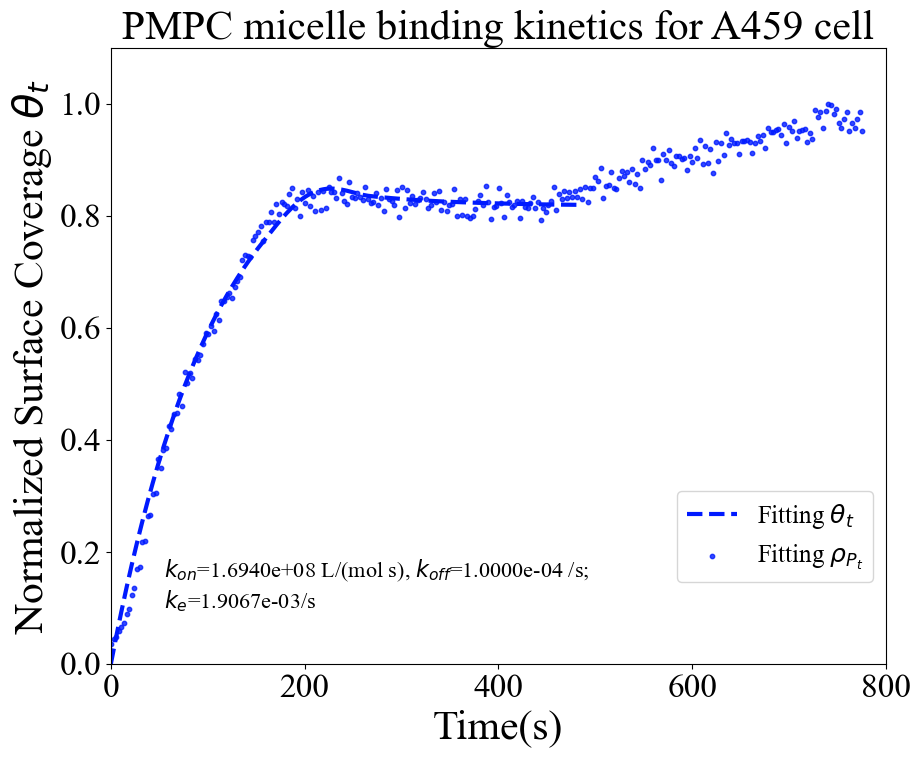

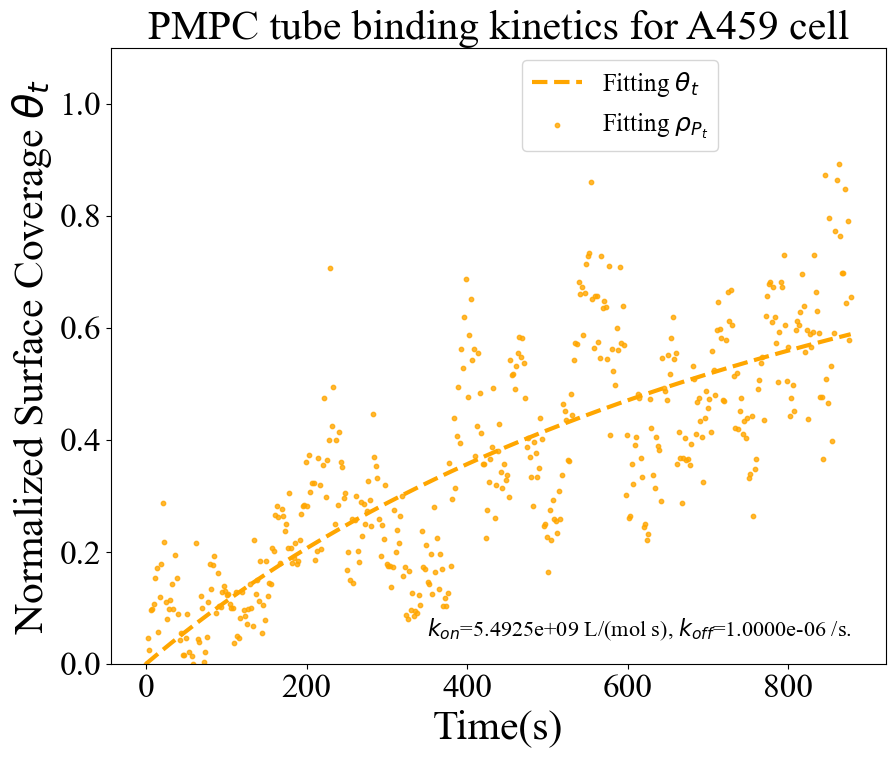

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import scipy.optimize as sci
from scipy.integrate import solve_ivp


def fit_fun_ves(t, kon0, koff0, a0, b0, ke0):
    global kon, a, b, f, koff, ke
    kon, koff = kon0, koff0
    a, b, ke = a0, b0, ke0

    res = solve_ivp(bind_ves, (0, 6000), [0, rho_P_ves], t_eval=t_fit_ves)
    y = res.y[0, :]
    return y

def bind_ves(t, ft):
    if t <= t_endo_ves:
        return kon*(1-a*ft[0])*(ft[1] - f * rho_P_ves * ft[0])*(1-ft[0]) - koff*(1-b*ft[0]) * ft[0], 0
    else:
        return kon*(ft[1] - f * rho_P_ves * ft[0])*(1-ft[0]) - koff*(1-b*ft[0]) * ft[0] - ke*ft[0], \
               -ke*ft[0] * f * rho_P_ves

def fit_fun_mi(t, kon0, koff0, a0, b0, ke0):
    global kon, a, b, koff, ke
    """Fitting parameters"""
    kon, koff = kon0, koff0
    a, b, ke = a0, b0, ke0

    mi = solve_ivp(bind_mi, (0, 6000), [0, rho_P_mi], t_eval=t_fit_mi)
    y = mi.y[0, :]
    return y

def bind_mi(t, ft):
    """=====***** 2.1.2. MIcelle mechanism function.*****====="""
    if t <= t_endo_mi:
        return kon*(1-a*ft[0])*(ft[1] - f * rho_P_ves * ft[0])*(1-ft[0]) - koff*(1-b*ft[0]) * ft[0], 0
    else:
        return kon*(1-a*ft[0])*(ft[1] - f * rho_P_ves * ft[0])*(1-ft[0]) - koff*(1-b*ft[0]) * ft[0] - ke*ft[0], \
               -ke*ft[0] * (f * rho_P_ves)

def fit_fun_tu(t, kon0, koff0, a0, b0):
    global kon, a, b, koff
    """Fitting parameters"""
    kon = kon0
    koff = koff0
    a = a0
    b = b0

    mi = solve_ivp(bind_tu, (0, 6000), [0, rho_P_tu], t_eval=t_fit_tu)
    y = mi.y[0, :]
    return y

def bind_tu(t, ft):
    return kon*(1-a*ft[0])*(ft[1] - f * rho_P_ves * ft[0])*(1-ft[0]) - koff * b * ft[0], 0


"""0.1 The fixed parameters. Cell Type. Density of different nanoparticle"""
# The parameters fixed at current time.
RD1 = 1
f = 0.01
fig_w, fig_h = 10, 8


PMPCMolarMass = 20 * 259.27 + 213.32 * 70  # 22415 g/mol sigle chain.
# 10**-4g (10ul*10-3*10mg/ml * 10-3) vesicle = 29423  Micelle 217 by valen
NA = 6.02*10**23
rho_P_ves = 1*10 ** -4/(PMPCMolarMass * 2 * 2471)  # R=40nm, N_PMPC = 2471
rho_P_mi = 1*10 ** -4/(PMPCMolarMass * 93)  # R=12nm, N_PMPC = 93
rho_P_tu = 1*10 ** -4/(PMPCMolarMass * 22414)  # R=20nm, L = 200, N_PMPC = 22414

data_ves = pd.read_excel("./Kinetics/DataKinetics_ParType.xlsx", sheet_name="Vesicle")
t_fit_ves = data_ves["Time"].values
data_fit_ves = data_ves["Fluorescence"].values / 100
t_exp_ves = data_ves["Time"].values
data_exp_ves = data_ves["Fluorescence"].values/100
t_endo_ves = t_exp_ves[70]  # The time start endocytosis.

"""=====*****1.1.3 Fitting process.1: Boundary 2: Get the fitting parameters.*****====="""
bound_ves = ([9.05 * 10**9, 1.25*10**-6, 0, 0, 0.008], [9.07 * 10**9, 1.28*10**-6, 1, 1, 0.01])
popt_ves, *pcov_ves = sci.curve_fit(fit_fun_ves, t_fit_ves, data_fit_ves, bounds=bound_ves)
kon, koff = popt_ves[0], popt_ves[1]
a, b, ke = popt_ves[2], popt_ves[3], popt_ves[4]
ka_ves = kon / koff

# Get the fitting data.
res_ves = solve_ivp(bind_ves, (0, 6000), [0, rho_P_ves], t_eval=t_fit_ves)
"""=====*****1.2.1 Plot setting: Plot element*****====="""
fig_ves, ax1 = plt.subplots(figsize=(fig_w, fig_h))

# Plot elements. x_data and y_data.
t_extend = np.arange(0, 50000, 1)
x_ves0, y_ves0 = res_ves.t, res_ves.y[0, :].T
x_ves1, y_ves1 = t_exp_ves, data_exp_ves
rho_P_real_time_ves = res_ves.y[1, :] - f * res_ves.y[0, :] * rho_P_ves
x_ves2, y_ves2 = x_ves0, rho_P_real_time_ves.T / (10**-12)

color0 = [0, 0, 0.8]
F1, F2, F3 = 30, 24, 18  # The titile, xlabel, and ylable fontsize.

"""=====*****1.2.2 Plot setting: curve and scatter colors.*****====="""
color_particle = [0, 0.5, 0.5]
color_ves, color_mi, color_tu = [1, 0.18, 0.18], [0,  0.1, 1], [1, 0.65, 0]  # orange color [1, 0.647, 0]

C_line, = ax1.plot(x_ves0, y_ves0, linewidth=3, color=color_ves, linestyle="--")  # ------------- x0,y0

"""=====*****1.2.2 Plot setting: title, labels and ticks(with limitation).*****====="""

title_ves = "PMPC vesicle binding kinetics for A459 cell"
xname, yname = "Time(s)", r"Normalized Surface Coverage $\theta_{t}$"
# 1
ax1.set_title(title_ves, fontsize=F1, fontname="Times New Roman")
ax1.set_xlabel(xname, fontsize=F1, fontname="Times New Roman", color=[0, 0, 0])
ax1.set_ylabel(yname, fontsize=F1, fontname="Times New Roman", color=[0, 0, 0])
# 2
plt.xticks([0, 500, 1000, 1500, 2000])
ax1.tick_params(axis='y', labelcolor=[0, 0, 0])  # Ticks
plt.xticks(fontsize=F2, fontname="Times New Roman")
plt.yticks(fontsize=F2, fontname="Times New Roman")

plt.ylim([0, 1.1])
plt.xlim([0, 2000])

# Scatter.
Scatter = ax1.scatter(x_ves1, y_ves1, color=color_ves, s=10, alpha=0.8, marker="o")

# The legend setting.
lines = [C_line, Scatter]
labels = [r"Fitting $\theta_{t}$", r"Fitting $\rho_{P_{t}}$", "Experiment"]
font_prop = FontProperties(family='Times New Roman', size=F3)
ax1.legend(lines, labels, bbox_to_anchor=[1, 1], ncol=1, shadow=False, fancybox=True, prop=font_prop)

# The text setting.
significant_digits = 4
kon1 = "{:.{}e}".format(kon, significant_digits)
koff1 = "{:.{}e}".format(koff, significant_digits)
ke1 = "{:.{}e}".format(ke, significant_digits)
rho_ves = "{:.{}e}".format(rho_P_ves, significant_digits)
text = r"$k_{on}$="+str(kon1)+" L/(mol s)"+r", $k_{off}$="+str(koff1)+" /s;" + "\n" + r"$k_{e}$=" + str(ke1) + "/s"
ax1.text(55, 0.1, text, fontsize=16, fontname="Times New Roman")
# Saving settings.
plt.savefig('./Pictures/PaperFitting{0}.png'.format(title_ves), dpi=800, bbox_inches='tight')


"""=====***** 2.1. MIcelle data.*****====="""
data_mi = pd.read_excel("./Kinetics/DataKinetics_ParType.xlsx", sheet_name="Micelle")
t_fit_mi = data_mi["Time"].values[:180]
data_fit_mi = data_mi["Fluorescence"].values[:180] / 100
t_exp_mi = data_mi["Time"].values
data_exp_mi = data_mi["Fluorescence"].values/100
t_endo_mi = t_exp_mi[70]

bound_mi = ([10**8, 10**-9, 0, 0, 0.001], [10 * 10**8, 10**-4, 1, 1, 0.004])
popt_mi, *pcov_mi = sci.curve_fit(fit_fun_mi, t_fit_mi, data_fit_mi, bounds=bound_mi)
kon, koff = popt_mi[0], popt_mi[1]
a, b, ke = popt_mi[2], popt_mi[3], popt_mi[4]

ka_mi = kon / koff

# Get the fitting data.
res_mi = solve_ivp(bind_mi, (0, 6000), [0, rho_P_mi], t_eval=t_fit_mi)

fig_mi, ax1 = plt.subplots(figsize=(fig_w, fig_h))
# Plot elements.
x_mi0, y_mi0 = res_mi.t, res_mi.y[0, :].T
x_mi1, y_mi1 = t_exp_mi, data_exp_mi
rho_P_real_time_mi = res_mi.y[1, :] - f * res_mi.y[0, :] * rho_P_ves
x_mi2, y_mi2 = x_mi0, rho_P_real_time_mi.T / (10**-11)

line0, = ax1.plot(x_mi0, y_mi0, linewidth=3, color=color_mi, linestyle="--")

# The ticks, tiltle and xlabel and ylabel.
title_mi = "PMPC micelle binding kinetics for A459 cell"
xname = "Time(s)"
yname = r"Normalized Surface Coverage $\theta _{t}$"
ax1.set_title(title_mi, fontsize=F1, fontname="Times New Roman")
ax1.set_xlabel(xname, fontsize=F1, fontname="Times New Roman", color=[0, 0, 0])
ax1.set_ylabel(yname, fontsize=F1, fontname="Times New Roman", color=[0, 0, 0])
ax1.tick_params(axis='y', labelcolor=[0, 0, 0])  # Ticks
plt.xticks(fontsize=F2, fontname="Times New Roman")
plt.yticks(fontsize=F2, fontname="Times New Roman")
plt.ylim([0, 1.1])
plt.xlim([0, 800])
plt.xticks([0, 200, 400, 600, 800])

# Line three.
line2 = ax1.scatter(x_mi1, y_mi1, color=color_mi, s=10, alpha=0.8, marker="o")

# The legend setting.
lines = [line0, line2]
labels = [r"Fitting $\theta_{t}$", r"Fitting $\rho_{P_{t}}$", "Experiment"]
font_prop = FontProperties(family='Times New Roman', size=F3)
ax1.legend(lines, labels, bbox_to_anchor=[1, 0.3], ncol=1, shadow=False, fancybox=True, prop=font_prop)
# The text setting.
kon1 = "{:.{}e}".format(kon, significant_digits)
koff1 = "{:.{}e}".format(koff, significant_digits)
ke1 = "{:.{}e}".format(ke, significant_digits)
rho_mi = "{:.{}e}".format(rho_P_mi, significant_digits)
text = r"$k_{on}$="+str(kon1)+" L/(mol s)" + r", $k_{off}$="+str(koff1)+" /s;" + "\n" + r"$k_{e}$=" + str(ke1) + "/s"
ax1.text(55, 0.1, text, fontsize=16, fontname="Times New Roman")
# Saving settings.
plt.savefig('./Pictures/PaperFitting{0}.png'.format(title_mi), dpi=800, bbox_inches='tight')


"""=====*****3.1 Tube data.*****====="""
data_tu = pd.read_excel("./Kinetics/DataKinetics_ParType.xlsx", sheet_name="Tube")
t_fit_tu = data_tu["Time"].values
data_fit_tu = data_tu["Fluorescence"].values / 100
t_exp_tu = data_tu["Time"].values
data_exp_tu = data_tu["Fluorescence"].values/100


bound_tu = ([1.5*10**9, 10**-6, 0, 0], [8*10**9, 10**-4, 1, 1])
popt_tu, *pcov_tu = sci.curve_fit(fit_fun_tu, t_fit_tu, data_fit_tu, bounds=bound_tu)
kon, koff = popt_tu[0], popt_tu[1]
a, b = popt_tu[2], popt_tu[3]
ka_tu = kon / koff

res_tu = solve_ivp(bind_tu, (0, 6000), [0, rho_P_tu], t_eval=t_fit_tu)


fig, ax1 = plt.subplots(figsize=(fig_w, fig_h))
"""Tube"""
x_tu0, y_tu0 = res_tu.t, res_tu.y[0, :].T
x_tu1, y_tu1 = t_exp_tu, data_exp_tu
rho_P_real_time_tu = res_tu.y[1, :] - f * res_tu.y[0, :]*rho_P_ves
x_tu2, y_tu2 = x_tu0, rho_P_real_time_tu.T / (10**-13)

line0, = ax1.plot(x_tu0, y_tu0, linewidth=3, color=color_tu, linestyle="--")  # ------------- x0,y0

# The ticks, tiltle and xlabel and ylabel.
title_tu = "PMPC tube binding kinetics for A459 cell"
xname = "Time(s)"
yname = r"Normalized Surface Coverage $\theta _{t}$"
ax1.set_title(title_tu, fontsize=F1, fontname="Times New Roman")
ax1.set_xlabel(xname, fontsize=F1, fontname="Times New Roman", color=[0, 0, 0])
ax1.set_ylabel(yname, fontsize=F1, fontname="Times New Roman", color=[0, 0, 0])
ax1.tick_params(axis='y', labelcolor=[0, 0, 0])  # Ticks
plt.xticks(fontsize=F2, fontname="Times New Roman")
plt.yticks(fontsize=F2, fontname="Times New Roman")
plt.ylim([0, 1.1])

# Line three.
line2 = ax1.scatter(x_tu1, y_tu1, color=color_tu, s=10, alpha=0.8, marker="o")

# The legend setting.
lines = [line0, line2]
labels = [r"Fitting $\theta_{t}$", r"Fitting $\rho_{P_{t}}$", "Experiment"]
font_prop = FontProperties(family='Times New Roman', size=F3)
ax1.legend(lines, labels, bbox_to_anchor=[0.8, 1], ncol=1, shadow=False, fancybox=True, prop=font_prop)

# The text setting.
kon1 = "{:.{}e}".format(kon, significant_digits)
koff1 = "{:.{}e}".format(koff, significant_digits)
ke1 = "{:.{}e}".format(ke, significant_digits)
rho_tu = "{:.{}e}".format(rho_P_ves, significant_digits)
text = r"$k_{on}$="+str(kon1)+" L/(mol s)"+r", $k_{off}$="+str(koff1)+" /s."
ax1.text(350, 0.05, text, fontsize=16, fontname="Times New Roman")
plt.savefig('./Pictures/PaperFitting{0}.png'.format(title_tu), dpi=800, bbox_inches='tight')
# plt.show()

print("Density of vesicle,", rho_P_ves, "\n",  "Density of micelle", rho_P_mi, "\n", "Density of tube:", rho_P_tu)
print("Vesicle", popt_ves, "Micelle", popt_mi, "Tube", popt_tu)
print("Avidity vesicle:", "{:.{}e}".format(ka_ves, 2), "micelle:", "{:.{}e}".format(ka_mi, 2), "tube:", "{:.{}e}".format(ka_tu, 2))
